### Planning a telescope observation

You want to know how likely it is that tomorrow night will be clear given the weather tonight (clear or cloudy). The key piece of information here is that the weather tomorrow depends on the weather today. From past history, you know that:

$$p({\rm clear \; tomorrow} \, |\,  {\rm cloudy \; today}) = 0.5,$$

which means that

$$p({\rm cloudy \; tomorrow} \, |\, {\rm cloudy \; today}) = 0.5.$$

We also have

$$p({\rm cloudy \; tomorrow} \, |\, {\rm clear \; today}) = 0.1,$$

which means that

$$p({\rm clear \; tomorrow} \, |\, {\rm clear \; today}) = 0.9.$$


- We can start with the sky conditions today and make predictions going forward more and more into the future.
- This will look like a big decision tree. 
- After enough days, we'll reach equilibrium probabilities that have to do with the mean weather statistics (ignoring seasons) and we'll arrive at

$$p({\rm clear}) = 0.83,$$

and 

$$p({\rm cloudy}) = 0.17.$$

You get the same answer for day $N$ as day $N+1$ and it doesn't matter whether it was clear or cloudy on the day that you started. The steps that we have taken in this process are, indeed, a **MARKOV CHAIN**.

Here is an illustration of this process:

![image.png](https://miro.medium.com/max/416/1*frksGjINf5oTjx7WL81U3w.png)

#### Tasks

- Start off on a cloud day. 
- Implement your weather forecast based on the above probabilities
- Run your simulator for N days (with $N\gtrsim 10^4$)
- Prepare a plot with the number of days on the x axis and the cumulative fraction of, say, sunny days over the number of days so far on the y axis. This is called a **trace-plot**, showing how our estimate of $p(\mathrm{clear})$ evolves as the chain samples.  
- Prepare a histogram of the above plot. This reveals the distribution of $p(\mathrm{clear})$.
- Use a summary statistics to determine the most likely value and an error on our estimate.

**Important:** 
- In MCMC the process must be **stationary** which basically means that the chain statistics look the same no matter which chunk you look at, e.g. first half, second half, or every other point, etc.  
- Obviously that isn't going to be the case in the early steps of the chain. In our example above, after some time the process was stationary, but not in the first few days.
- So, there is a **burn-in** phase that needs to be discarded. How one determines the number of early steps to discard as burn-in is tricky, but ***you should always start with a traceplot of your samples!***


#### Tasks

- In the above example, experiment with chopping off different numbers of initial points as burn-in.




In [269]:
import numpy as np
from scipy import stats
import pylab as plt

#cloudy = 0
#clear = 1

#Implementiamo una matrice sulle probabilità di transizione 
p_from_0 = np.array([[0.5], [0.5]])
p_from_1 = np.array([[0.1], [0.9]])

T_matrix = np.vstack((p_from_0.T, p_from_1.T))



In [270]:
#Creiamo una funzione che simuli la markov chain

def markov_chain(initial_day, n_steps):
    meteo = np.zeros(int(n_steps) + 1)
    meteo[0] = (int(initial_day))
    randoms = np.random.rand(int(n_steps))
    
    for i in range(int(n_steps)):
        prev_day = meteo[i]
        rng = randoms[i]
        
        if prev_day == 1: #IERI = CLEAR
            if rng <= p_from_1[0]: #metropolis step, se l'rng è minore della probabilità di transizione allora è accetto e il giorno dopo sarà nuvoloso
                meteo[i+1] = 0 #DOMANI = CLOUDY
            else:
                meteo[i+1] = 1 #DOMANI = CLEAR
                
        elif prev_day == 0: #IERI = CLOUDY
            if rng <= p_from_0[0]:
                meteo[i+1] = 0 #DOMANI = CLOUDY
            else: 
                meteo[i+1] = 1 #DOMANI = CLEAR

    meteo = np.array(meteo)

    #Prepariamo il plot con il numero di giorni sull'asse x e la frazione cumulativa (cumsum) di giorni soleggiati sul numero di giorni
    #questo plot è detto "trace-plot" ed è una stima di come la p(clear) evolve lungo la catena

    length = meteo.shape[0]
    index_array = np.arange(length) + 1

    trace_clear = np.cumsum(meteo == 1)/index_array
    trace_cloudy = np.cumsum(meteo==0)/index_array

    
    return meteo, trace_clear, trace_cloudy

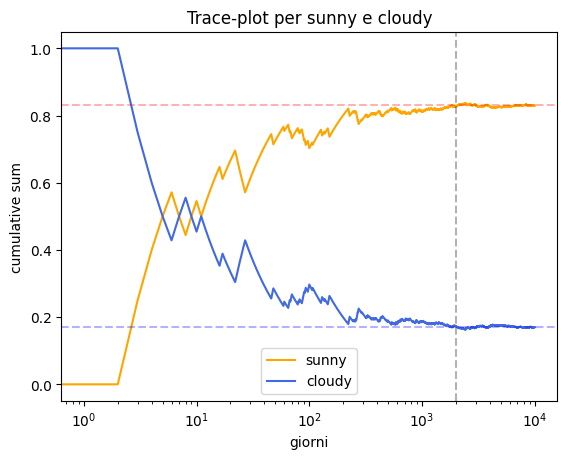

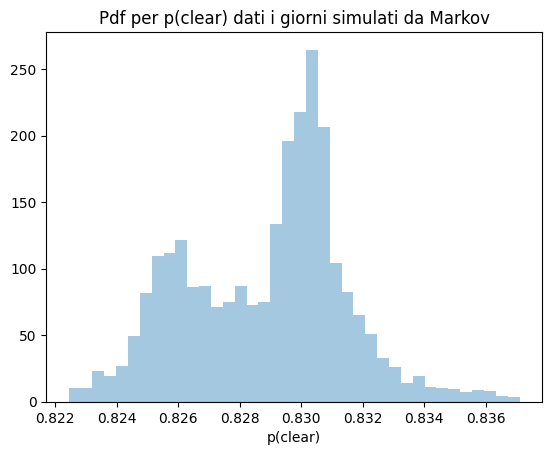

In [271]:
#Definiamo il numero di giorni e facciamo andare la simulazione
N = 1e4
meteo, trace_clear, trace_cloudy = markov_chain(0, N)
burn_in = int(2e3)
plt.plot(trace_clear, label = 'sunny', color = 'orange')
plt.plot(trace_cloudy, label ='cloudy', color = 'royalblue')
plt.axvline(burn_in, alpha = 0.3, linestyle = '--', color = 'black')
plt.xscale('log')
plt.axhline(0.83, alpha = 0.3, linestyle = '--', color = 'red')
plt.axhline(0.17, alpha = 0.3, linestyle = '--', color = 'blue')
plt.legend()
plt.title('Trace-plot per sunny e cloudy')
plt.xlabel('giorni')
plt.ylabel('cumulative sum')
plt.savefig("./Images/EX_7_TracePlots.png")
plt.show()

#Il trace plot ci mostra che la catena ha raggiunto l'equilibrio, dimenticando lo stato iniziale. Ci permette di vedere più o meno il burn-in
#ovvero quanti step buttare 
meteo = meteo[(burn_in):]
trace_clear = trace_clear[(burn_in):]
trace_cloudy = trace_cloudy[(burn_in):]

plt.hist(trace_clear, bins = 'auto', density = True, alpha = 0.4);
plt.xlabel('p(clear)')
plt.title('Pdf per p(clear) dati i giorni simulati da Markov')
plt.savefig("./Images/EX_7_PdfClear.png")
#La traccia è la frazione cumulativa di giorni di sole fino a quel momento. Dopo il burn in inizia a fluttuare attorno al valore teorico
#ecco il motivo per cui l'istogramma è piccato sul valore teorico, è il valore in cui la catena passa più tempo
#in questo caso i parametri da stimare era la probabilità di avere una giornata soleggiata, le probabilità di transizioni fanno parte delle assunzioni


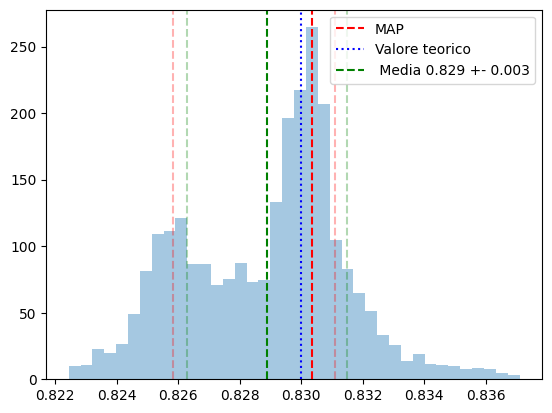

In [286]:
#Stimiamo le statistiche del nostro parametro
counts, bin_edges = np.histogram(trace_clear, bins = 'auto', density = True)


#MAP (maximum a posteriori). Troviamo il bin con la frequenza più alta e il MAP sarà al centro di quel bin
max_bin = np.argmax(counts)
MAP = (bin_edges[max_bin] + bin_edges[max_bin+ 1]) / 2

#Facciamo gli intervalli di credibilità percentili
lower = np.percentile(trace_clear, 15.87)
upper = np.percentile(trace_clear, 84.13)

plt.hist(trace_clear, bins = 'auto', density = True, alpha = 0.4);
plt.axvline(MAP, color = 'red', linestyle = '--', label='MAP')
plt.axvline(0.83, color = 'blue', linestyle = 'dotted', label='Valore teorico')
plt.axvline(lower, color = 'red', linestyle = '--', alpha = 0.3)
plt.axvline(upper, color = 'red', linestyle = '--', alpha = 0.3)
plt.axvline(np.mean(trace_clear), color = 'green', linestyle = '--', label = f' Media {np.mean(trace_clear):.3f} +- {np.std(trace_clear):.3f}')
plt.axvline(np.mean(trace_clear) + np.std(trace_clear), color = 'green', linestyle = '--', alpha = 0.3)
plt.axvline(np.mean(trace_clear) - np.std(trace_clear), color = 'green', linestyle = '--', alpha = 0.3)

plt.legend()
plt.savefig("./Images/EX_7_ClearStatistics.png")


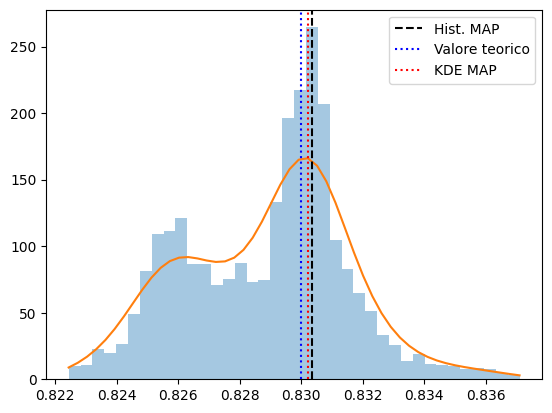

In [287]:
#Proviamo ad usare il KDE per una forma analitica della pdf.
from sklearn.neighbors import KernelDensity
kde_skl = KernelDensity(bandwidth = 0.001, kernel = "gaussian")
kde_skl.fit(trace_clear[:, np.newaxis])
ax = np.linspace(np.min(trace_clear), np.max(trace_clear))
log_pdf = kde_skl.score_samples(ax[:, np.newaxis])
p_clear_pdf = np.exp(log_pdf)
plt.hist(trace_clear, bins = 'auto', density = True, alpha = 0.4);
plt.plot(ax, p_clear_pdf)
plt.axvline(MAP, color = 'black', linestyle = '--', label='Hist. MAP')
plt.axvline(0.83, color = 'blue', linestyle = 'dotted', label='Valore teorico')
#con la pdf fittata proviamo a vedere la media a cosa corrisponde
pdf_map = np.argmax(p_clear_pdf)
map_val = ax[pdf_map]
plt.axvline(map_val, color = 'red', linestyle = 'dotted', label='KDE MAP')
plt.savefig("./Images/EX_7_KDEClear.png")
plt.legend()

#### (Optional, not examinable) Finance

- Redo the same for the Markovian process describing the stock market (see above in this notebook). If you've written your code well, this should require minor modifications.

[[0.9   0.075 0.025]
 [0.15  0.8   0.05 ]
 [0.25  0.25  0.5  ]]
[1.         1.         1.         ... 0.06821364 0.06820682 0.0682    ]


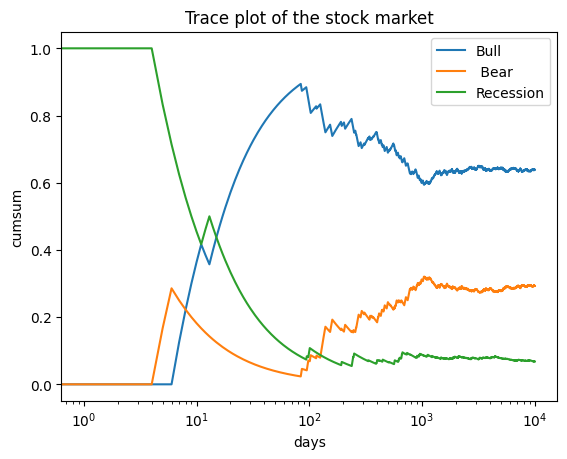

In [288]:
#NOTE:
#BULL = 0 (GROWING PRICES)
#BEAR = 1 (DECREASING PRICES)
#STAGNANT = 2 (RECESSION)


p_from_0 = np.array([[0.9], [0.075], [0.025]])
p_from_1 = np.array([[0.15], [0.8], [0.05]])
p_from_2 = np.array([[0.25], [0.25], [0.5]])

transition_matrix = np.vstack((p_from_0.T, p_from_1.T, p_from_2.T))

print(transition_matrix)

def markov_chain():

    stack = [2] #starting from a BULL state

    for k in range(1,10000):
        rng = np.random.rand()
        #forecasting
        if stack[k-1] == 0:
            if rng <= p_from_0[0]:
                stack.append(0)
            elif rng > p_from_0[0] and rng <= (p_from_0[1] + p_from_0[0]):
                stack.append(1)                
            else: 
                stack.append(2)
                
        elif stack[k-1] == 1:
            if rng <= p_from_1[0]:
                stack.append(0)
            elif rng > p_from_1[0] and rng <= (p_from_1[1] + p_from_1[0]):
                stack.append(1)                
            else: 
                stack.append(2)

        elif stack[k-1] == 2:
            if rng <= p_from_2[0]:
                stack.append(0)
            elif rng > p_from_2[0] and rng <= (p_from_2[1] + p_from_2[0]):
                stack.append(1)                
            else: 
                stack.append(2)
                
    stack = np.array(stack)

    length = stack.shape[0]

    index_array = np.arange(length) + 1
    trace_bull = np.cumsum(stack == 0)/index_array
    trace_bear = np.cumsum(stack == 1)/index_array
    trace_recession = np.cumsum(stack == 2)/index_array
    
    return trace_bull, trace_bear, trace_recession, stack

trace_bull, trace_bear, trace_recession, stack = markov_chain()


plt.plot(trace_bull, label='Bull')
plt.plot(trace_bear, label=' Bear')
plt.plot(trace_recession, label='Recession')
print(trace_recession)
plt.xscale('log')
plt.xlabel("days")
plt.ylabel("cumsum")
plt.title("Trace plot of the stock market")
plt.legend()
plt.savefig("./Images/EX_7_StockTraces.png")

In [283]:
trace_bull = trace_bull[(burn_in):]
trace_bear = trace_bear[(burn_in):]
trace_recession = trace_recession[(burn_in):]
print(f"Bull probabilità media = {np.mean(trace_bull):.3f} +- {np.std(trace_bull):.3f}")
print(f"Bear probabilità media = {np.mean(trace_bear):.3f} +- {np.std(trace_bear):.3f}")
print(f"Recession probabilità media = {np.mean(trace_recession):.3f} +- {np.std(trace_recession):.3f}")


Bull probabilità media = 0.620 +- 0.003
Bear probabilità media = 0.322 +- 0.003
Recession probabilità media = 0.058 +- 0.001
